In [174]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("players_data-2025_2026.csv", encoding='ISO-8859-1')

# Filter players with meaningful data
df = df[df['Min'] >= 90].copy()

print("Shape after filtering:", df.shape)
df.head()

Shape after filtering: (2333, 102)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,27,21,...,1,0,0,14,37,5,30,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,16,3,...,0,0,0,4,3,1,25,2,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0
5,6,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32.0,1993.0,15,11,...,4,1,1,14,13,0,24,9,8,0


In [175]:
# Create Expected Goals (xG)
df["xG"] = df["SoT"] * df["G/Sh"]

In [176]:
# Clean columns
df.columns = df.columns.str.strip()
df = df.drop(columns=['Player', 'Nation', 'Squad', 'Comp', 'Rk'], errors='ignore')

# Numeric selection
df_numeric = df.select_dtypes(include=[np.number])
df_numeric = df_numeric.fillna(df_numeric.mean())

# Target & features
y = df_numeric['xG']
X = df_numeric.drop(columns=['xG'])

# Remove leakage features
X = X.drop(columns=[col for col in X.columns 
                    if 'gls' in col.lower() 
                    or 'g/sh' in col.lower() 
                    or 'g+a' in col.lower()], errors='ignore')

In [177]:
print(df.columns)

Index(['Pos', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A',
       'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper',
       'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper',
       'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper',
       'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA',
       'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%',
       'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting',
       'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting',
       'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting',
       'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh',
       'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting',
       'Rk_stats_playing_time', 'Nation_stats_playing_time',
       'Pos_stats_playing_time', 'Comp_stats_playing_time',
       'Age_stats_playing_time', 'Born_stats_playing_time',
       'MP_stats_pla

In [178]:
# Normalize features (important for gradient descent)
X = (X - X.mean()) / X.std()

X.head()

,Age,Born,MP,Starts,Min,90s,Ast,G-PK,PK,PKatt,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,-0.240210,0.188944,1.509796,1.198634,1.130524,1.131764,1.378754,1.343885,-0.221354,-0.245270,...,-0.553078,-0.313460,-0.191035,0.150939,2.276883,1.076471,0.424605,0.491159,1.255942,-0.201319
1,-1.618835,1.568621,-1.956270,-1.366882,-1.397654,-1.402070,-0.664418,-0.627991,-0.221354,-0.245270,...,-1.063897,-0.313460,-0.191035,-1.071067,-0.987278,-0.577294,-0.574136,-0.750797,-0.877920,-0.201319
2,-1.389064,1.568621,-0.015273,-1.110331,-0.834491,-0.829914,-0.664418,0.357947,-0.221354,-0.245270,...,-1.063897,-0.313460,-0.191035,-0.867399,-0.805935,-0.246541,0.239653,-0.750797,-0.984614,-0.201319
4,-0.010440,-0.041002,-0.431201,-0.084124,-0.151732,-0.148776,-0.664418,-0.627991,2.976288,2.499161,...,-0.553078,-0.313460,-0.191035,0.354607,0.010105,-0.246541,-0.352194,0.491159,0.722477,-0.201319
5,1.368185,-1.420679,-0.153915,-0.084124,-0.204718,-0.203267,-0.664418,-0.135022,-0.221354,-0.245270,...,0.979381,2.772203,4.991351,0.150939,0.100776,-0.577294,0.202662,0.039539,-0.237762,-0.201319


In [179]:
# Convert to numpy arrays
X = X.values
y = y.values

# Add bias column (intercept)
X = np.c_[np.ones(X.shape[0]), X]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2333, 76)
y shape: (2333,)


In [180]:
def compute_cost(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(theta) - y)**2)


def gradient_descent(X, y, theta, lr, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        error = X.dot(theta) - y
        theta = theta - (lr/m) * X.T.dot(error)
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

In [181]:
# Training
theta = np.zeros(X.shape[1])

theta, cost_history = gradient_descent(X, y, theta, 0.01, 1000)

In [182]:
# Predict using trained theta
y_pred = X.dot(theta)

print("Predictions sample:")
print(y_pred[:10])

Predictions sample:
[1.68236986 0.27779173 0.68280794 0.1835622  0.43214912 0.18554616
 0.0969801  0.33561927 1.42539875 1.25287756]


In [183]:
print("Actual vs Predicted (first 10):\n")

for i in range(10):
    print(f"Actual: {y[i]:.3f}  |  Predicted: {y_pred[i]:.3f}")

Actual vs Predicted (first 10):

Actual: 1.650  |  Predicted: 1.682
Actual: 0.566  |  Predicted: 0.278
Actual: 0.520  |  Predicted: 0.683
Actual: 0.000  |  Predicted: 0.184
Actual: 0.250  |  Predicted: 0.432
Actual: 0.566  |  Predicted: 0.186
Actual: 0.000  |  Predicted: 0.097
Actual: 0.250  |  Predicted: 0.336
Actual: 1.120  |  Predicted: 1.425
Actual: 1.000  |  Predicted: 1.253


In [184]:
errors = y - y_pred

print("Error sample:")
print(errors[:10])

Error sample:
[-0.03236986  0.28809483 -0.16280794 -0.1835622  -0.18214912  0.38034039
 -0.0969801  -0.08561927 -0.30539875 -0.25287756]


In [185]:
mae = np.mean(np.abs(errors))
print("MAE:", mae)

MAE: 0.15565514687423657


In [186]:
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)

r2 = 1 - (ss_residual / ss_total)
print("R² Score:", r2)

R² Score: 0.9436579687622427


In [187]:
rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)

RMSE: 0.21330077696799174


In [188]:
print("\nFormatted Predictions Sample:")
for i in range(10):
    print(f"{i+1}. Predicted: {y_pred[i]:.4f}")


Formatted Predictions Sample:
1. Predicted: 1.6824
2. Predicted: 0.2778
3. Predicted: 0.6828
4. Predicted: 0.1836
5. Predicted: 0.4321
6. Predicted: 0.1855
7. Predicted: 0.0970
8. Predicted: 0.3356
9. Predicted: 1.4254
10. Predicted: 1.2529


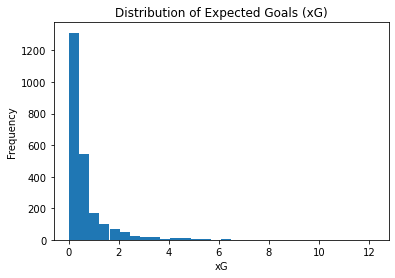

In [189]:
# xG Distribution
plt.hist(y, bins=30)
plt.title("Distribution of Expected Goals (xG)")
plt.xlabel("xG")
plt.ylabel("Frequency")
plt.show()

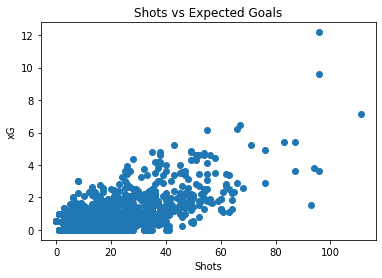

In [190]:
plt.scatter(df_numeric['Sh'], y)
plt.title("Shots vs Expected Goals")
plt.xlabel("Shots")
plt.ylabel("xG")
plt.show()

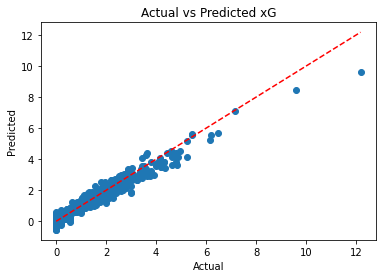

In [191]:
plt.scatter(y, y_pred)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
plt.title("Actual vs Predicted xG")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()